# Создание модели ранжирования для персонализированных рекомендаций

Имеется 4 файла с данными - `items.csv`, `users.csv`, `train_interactions.csv` и `test_interactions.csv` для тренировки и тестирования моделей соответственно.

В файле `train_interactions.csv` есть поле `relevance`, а в `test_interactions.csv` его нет.

Необходимо предсказать числовое поле `relevance` для данных в файле `test_interactions.csv`.

При помощи этой модели интернет-магазин сможет рекомендовать релевантные товары пользователям первее, что повысит CTR (click-through rate) и другие важные бизнес-метрики.

Файл должен иметь размерность `3993` строк на `3` столбца с полями `user_id`, `item_id` и `relevance`.

Минимальное значение метрики `Average NDCG@5: 0.9`

In [29]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler, LabelEncoder, OrdinalEncoder
import xgboost as xgb
from sklearn.metrics import ndcg_score
import matplotlib.pyplot as plt

## 1. Загрузка датасетов

In [5]:
items = pd.read_csv('items.csv')
users = pd.read_csv('users.csv')
train_interactions = pd.read_csv('train_interactions.csv')
test_interactions = pd.read_csv('test_interactions.csv')

In [25]:
# Выводим информацию о размерах данных
print(f"Товары: {items.shape[0]} записей")
print(f"Пользователи: {users.shape[0]} записей")
print(f"Обучающая выборка: {train_interactions.shape[0]} записей")
print(f"Тестовая выборка: {test_interactions.shape[0]} записей")

Товары: 120 записей
Пользователи: 900 записей
Обучающая выборка: 16007 записей
Тестовая выборка: 3993 записей


In [27]:
# Просматриваем первые несколько строк каждого датафрейма
print("Пример товаров:")
display(items.head())

print("Пример пользователей:")
display(users.head())

print("Пример обучающих взаимодействий:")
display(train_interactions.head())

print("Пример тестовых взаимодействий:")
display(test_interactions.head())

Пример товаров:


,item_id,category,complexity,popularity
0,1,books,0.505081,0.167167
1,2,furniture,1.150973,0.804426
2,3,electronics,0.840617,0.338849
3,4,clothing,0.701612,0.259990
4,5,electronics,1.007673,0.722456


Пример пользователей:


,user_id,age,income_level
0,1,56,medium
1,2,46,high
2,3,32,low
3,4,60,medium
4,5,25,low


Пример обучающих взаимодействий:


,user_id,item_id,relevance
0,846,34,3
1,124,52,3
2,414,6,3
3,725,2,3
4,172,15,3


Пример тестовых взаимодействий:


,user_id,item_id
0,488,6
1,827,114
2,626,41
3,790,83
4,544,10


# 2. EDA
## Анализ распределения целевой переменной

Статистика relevance в обучающей выборке:
count    16007.000000
mean         3.398826
std          0.611742
min          1.000000
25%          3.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: relevance, dtype: float64


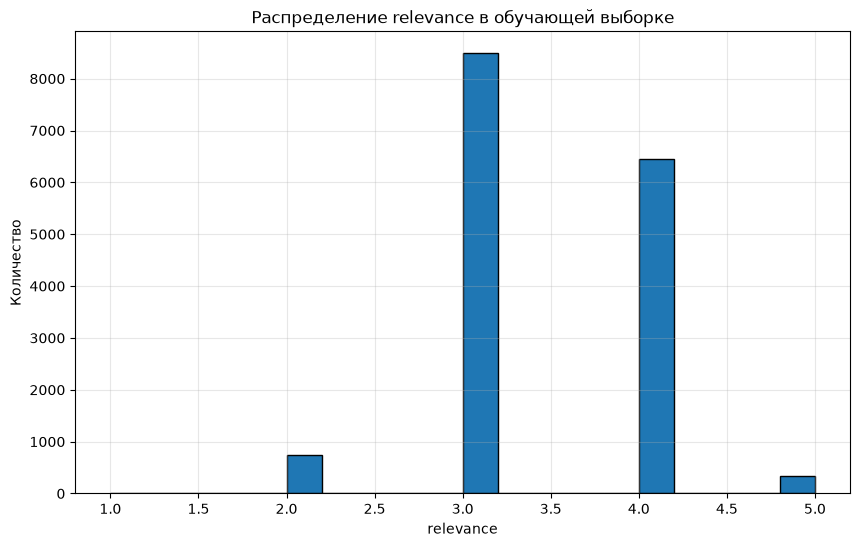

Количество уникальных значений: 5


In [34]:
print("Статистика relevance в обучающей выборке:")
print(train_interactions['relevance'].describe())

# Визуализируем распределение relevance
plt.figure(figsize=(10, 6))
train_interactions['relevance'].hist(bins=20, edgecolor='black')
plt.title('Распределение relevance в обучающей выборке')
plt.xlabel('relevance')
plt.ylabel('Количество')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Количество уникальных значений: {train_interactions['relevance'].nunique()}")

## Анализ категориальных признаков

Распределение категорий товаров:
category
electronics    32
clothing       32
furniture      29
books          27
Name: count, dtype: int64




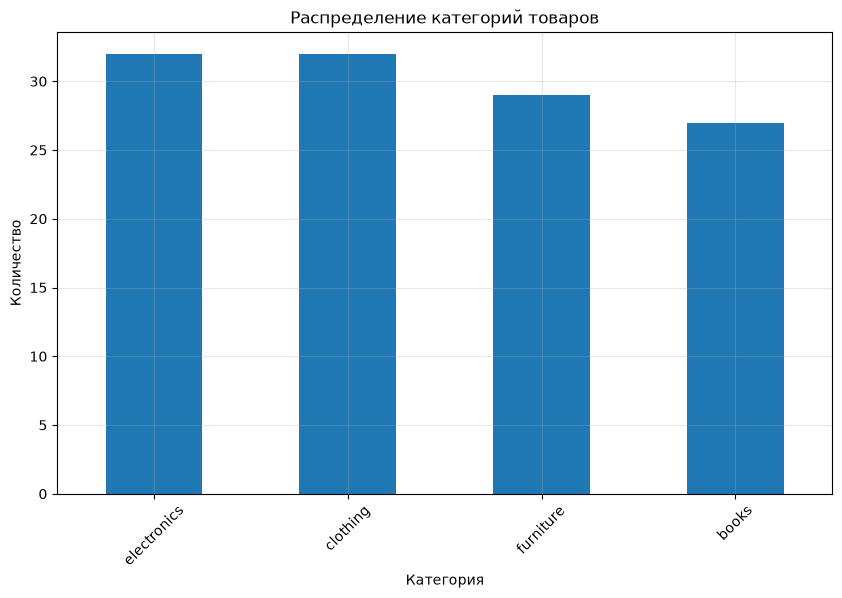


Распределение уровней дохода пользователей:
income_level
medium    478
low       241
high      181
Name: count, dtype: int64




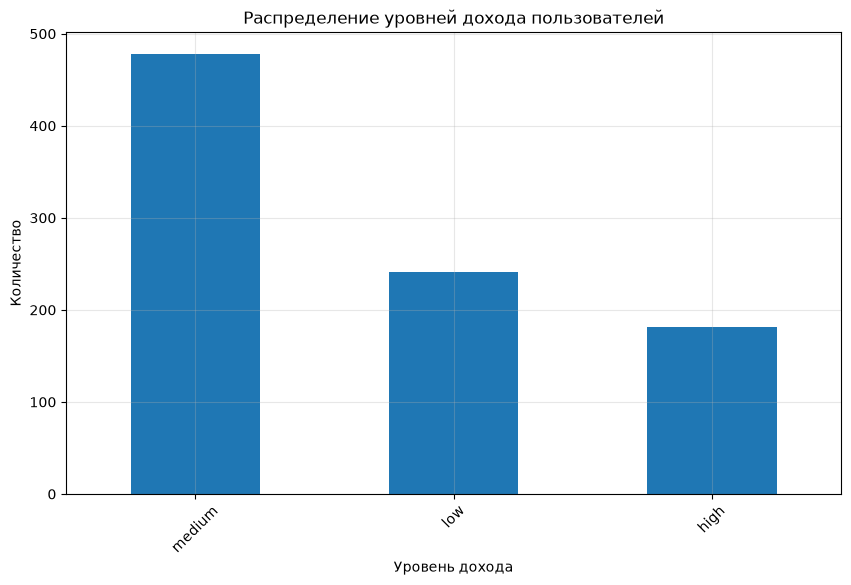


Статистика возраста пользователей:
count    900.000000
mean      41.081111
std       13.397619
min       18.000000
25%       30.000000
50%       42.000000
75%       52.000000
max       64.000000
Name: age, dtype: float64


In [35]:
# Анализируем категории товаров
print("Распределение категорий товаров:")
print(items['category'].value_counts())
print("\n")

# Визуализация категорий
plt.figure(figsize=(10, 6))
items['category'].value_counts().plot(kind='bar')
plt.title('Распределение категорий товаров')
plt.xlabel('Категория')
plt.ylabel('Количество')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

# Анализируем уровень дохода пользователей
print("\nРаспределение уровней дохода пользователей:")
print(users['income_level'].value_counts())
print("\n")

# Визуализация уровня дохода
plt.figure(figsize=(10, 6))
users['income_level'].value_counts().plot(kind='bar')
plt.title('Распределение уровней дохода пользователей')
plt.xlabel('Уровень дохода')
plt.ylabel('Количество')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

# Статистика возраста пользователей
print("\nСтатистика возраста пользователей:")
print(users['age'].describe())

## Анализ числовых признаков

Статистика числовых признаков товаров:
       complexity  popularity
count  120.000000  120.000000
mean     0.907232    0.530771
std      0.572468    0.267762
min      0.141125    0.109385
25%      0.460800    0.302882
50%      0.752367    0.521327
75%      1.203565    0.779453
max      2.508532    0.992430




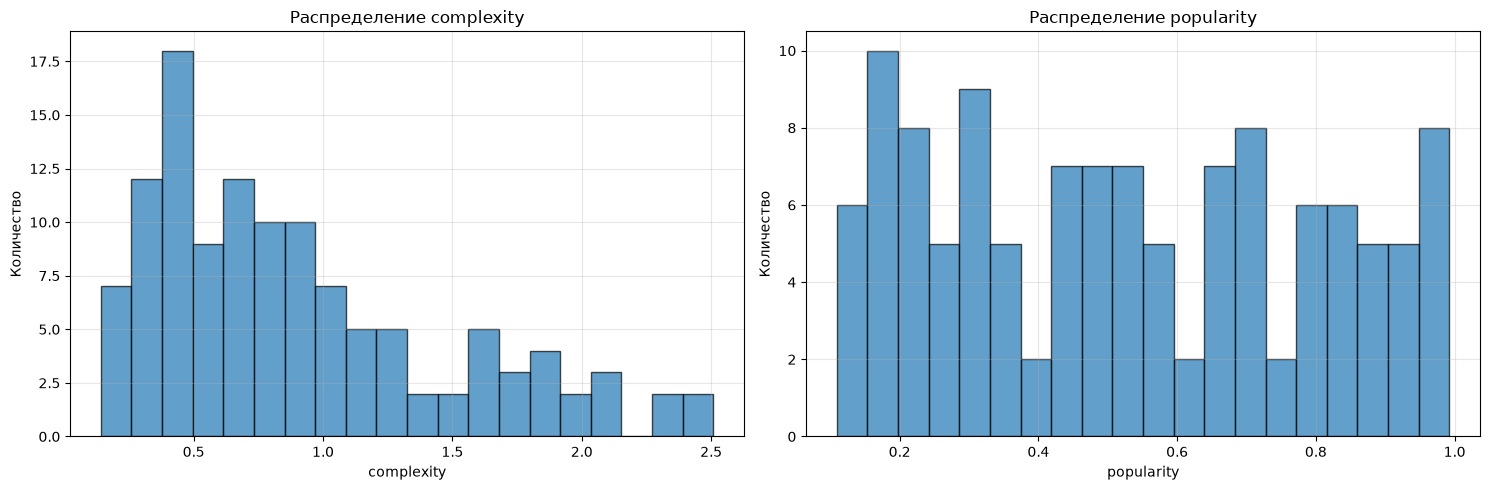


Корреляция между признаками товаров:
            complexity  popularity
complexity     1.00000    -0.00541
popularity    -0.00541     1.00000


In [36]:
# Статистика числовых признаков товаров
print("Статистика числовых признаков товаров:")
print(items[['complexity', 'popularity']].describe())
print("\n")

# Визуализация распределения числовых признаков
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# complexity
axes[0].hist(items['complexity'], bins=20, edgecolor='black', alpha=0.7)
axes[0].set_title('Распределение complexity')
axes[0].set_xlabel('complexity')
axes[0].set_ylabel('Количество')
axes[0].grid(True, alpha=0.3)

# popularity
axes[1].hist(items['popularity'], bins=20, edgecolor='black', alpha=0.7)
axes[1].set_title('Распределение popularity')
axes[1].set_xlabel('popularity')
axes[1].set_ylabel('Количество')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Корреляция между признаками товаров
print("\nКорреляция между признаками товаров:")
print(items[['complexity', 'popularity']].corr())

## Анализ взаимодействий пользователей с товарами

Статистика количества взаимодействий на пользователя:
count    720.000000
mean      22.231944
std        5.015451
min        8.000000
25%       19.000000
50%       22.000000
75%       26.000000
max       40.000000
dtype: float64


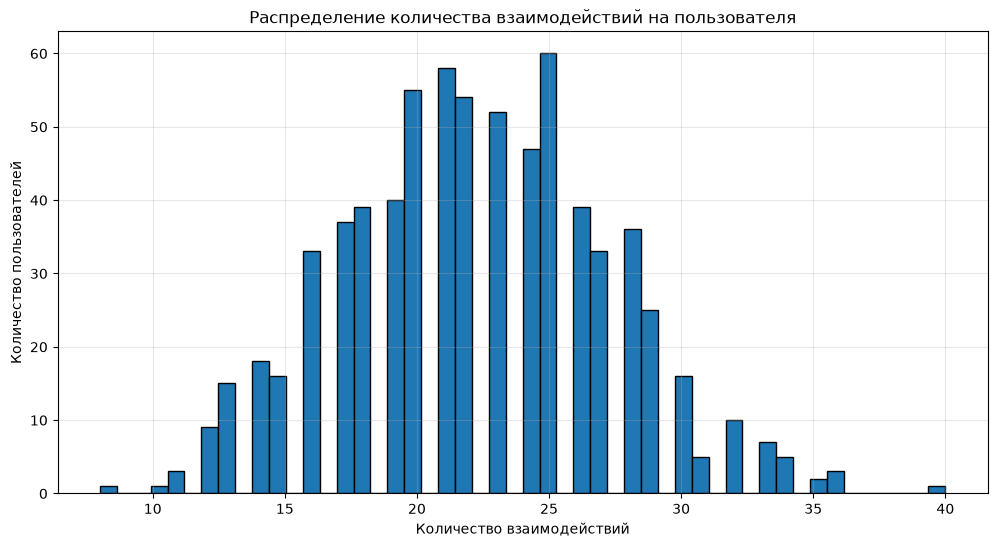


Статистика количества взаимодействий на товар:
count    120.000000
mean     133.391667
std       10.373120
min      103.000000
25%      126.750000
50%      133.000000
75%      140.000000
max      164.000000
dtype: float64


In [37]:
# Количество взаимодействий на пользователя
user_interactions = train_interactions.groupby('user_id').size()
print("Статистика количества взаимодействий на пользователя:")
print(user_interactions.describe())

# Визуализация количества взаимодействий
plt.figure(figsize=(12, 6))
user_interactions.hist(bins=50, edgecolor='black')
plt.title('Распределение количества взаимодействий на пользователя')
plt.xlabel('Количество взаимодействий')
plt.ylabel('Количество пользователей')
plt.grid(True, alpha=0.3)
plt.show()

# Количество взаимодействий на товар
item_interactions = train_interactions.groupby('item_id').size()
print("\nСтатистика количества взаимодействий на товар:")
print(item_interactions.describe())

## Анализ средней relevance по категориям

Средняя relevance по категориям:
category
clothing       3.412395
electronics    3.408415
furniture      3.404483
books          3.364933
Name: relevance, dtype: float64


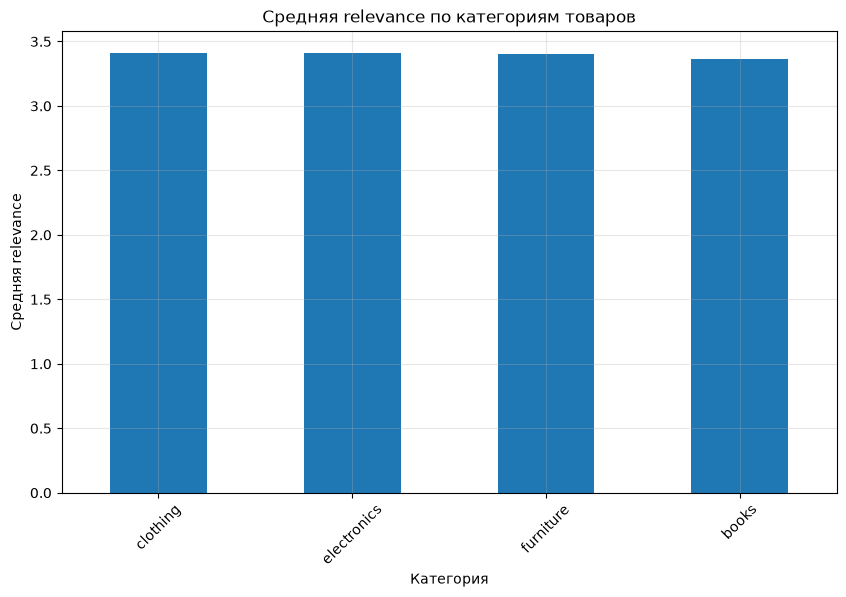

In [38]:
# Объединяем данные для анализа
train_merged = train_interactions.merge(items, on='item_id')

# Средняя relevance по категориям
avg_relevance_by_category = train_merged.groupby('category')['relevance'].mean().sort_values(ascending=False)
print("Средняя relevance по категориям:")
print(avg_relevance_by_category)

# Визуализация
plt.figure(figsize=(10, 6))
avg_relevance_by_category.plot(kind='bar')
plt.title('Средняя relevance по категориям товаров')
plt.xlabel('Категория')
plt.ylabel('Средняя relevance')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

# Предобработка данных

In [39]:
def preprocess_data(interactions, users_df, items_df):
    """
    Функция для предобработки данных:
    1. Объединение взаимодействий с данными пользователей и товаров
    2. Кодирование категориальных признаков
    3. Возврат фичей, целевой переменной и групп
    """
    # Объединяем данные
    data = interactions.merge(users_df, on='user_id').merge(items_df, on='item_id')
    
    # Кодируем категориальные признаки
    le_category = LabelEncoder()
    le_income = LabelEncoder()
    
    data['category_encoded'] = le_category.fit_transform(data['category'])
    data['income_level_encoded'] = le_income.fit_transform(data['income_level'])
    
    # Удаляем исходные категориальные колонки и идентификаторы
    features = data.drop(columns=['user_id', 'item_id', 'category', 'income_level'])
    
    # Если есть relevance, сохраняем его отдельно
    if 'relevance' in features.columns:
        relevance = features['relevance'].values
        features = features.drop(columns=['relevance'])
    else:
        relevance = None
    
    # Группы по user_id для ранжирования
    groups = data['user_id'].values
    
    return features.values, relevance, groups, le_category, le_income

# Применяем к обучающим данным
X_train, y_train, groups_train, le_category, le_income = preprocess_data(
    train_interactions, users, items
)

print(f"Размерность обучающей выборки: {X_train.shape}")
print(f"Количество групп (пользователей): {len(np.unique(groups_train))}")
print(f"Количество признаков: {X_train.shape[1]}")

Размерность обучающей выборки: (16007, 5)
Количество групп (пользователей): 720
Количество признаков: 5


## Масштабирование числовых признаков

In [ ]:
# Нормализуем числовые признаки для улучшения сходимости
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

print("Признаки успешно масштабированы!")
print(f"Среднее значение после масштабирования: {X_train_scaled.mean(axis=0)[:5]}")
print(f"Стандартное отклонение после масштабирования: {X_train_scaled.std(axis=0)[:5]}")

Признаки успешно масштабированы!
Среднее значение после масштабирования: [-1.53365724e-16  2.77434379e-17  4.01946928e-16 -1.03649484e-16
 -4.61650806e-17]
Стандартное отклонение после масштабирования: [1. 1. 1. 1. 1.]


## Подготовка данных для XGBoost ранжирования

In [ ]:
def create_lambdamart_dataset(X, y, groups):
    """
    Создание DMatrix для XGBoost с поддержкой ранжирования
    """
    # Получаем размеры групп
    unique_groups = np.unique(groups)
    group_sizes = []
    
    for group in unique_groups:
        group_sizes.append(np.sum(groups == group))
    
    # Создаем DMatrix
    dmatrix = xgb.DMatrix(X, label=y)
    dmatrix.set_group(group_sizes)
    
    return dmatrix

# Создаем обучающий датасет
dtrain = create_lambdamart_dataset(X_train_scaled, y_train, groups_train)

print("DMatrix для обучения успешно создан!")
print(f"Количество групп: {len(np.unique(groups_train))}")

DMatrix для обучения успешно создан!
Количество групп: 720


# Обучение модели LambdaMART

In [ ]:
# Параметры для LambdaMART
params = {
    'objective': 'rank:ndcg',          # Оптимизируем NDCG
    'learning_rate': 0.1,              # Скорость обучения
    'max_depth': 6,                    # Глубина деревьев
    'min_child_weight': 5,            # Минимальный вес ребенка
    'subsample': 0.8,                 # Подвыборка для каждого дерева
    'colsample_bytree': 0.8,          # Подвыборка признаков для каждого дерева
    'eval_metric': 'ndcg@5',          # Метрика для оценки
    'early_stopping_rounds': 20,      # Ранняя остановка
    'verbosity': 0,                   # Отключаем вывод
    'seed': 42                        # Для воспроизводимости
}

# Создаем валидационную выборку (20% данных)
# Важно: валидация должна учитывать группы пользователей
unique_users = np.unique(groups_train)
np.random.seed(42)
val_users = np.random.choice(unique_users, size=int(0.2 * len(unique_users)), replace=False)

# Создаем маски для обучения и валидации
train_mask = np.isin(groups_train, [u for u in unique_users if u not in val_users])
val_mask = np.isin(groups_train, val_users)

# Подготовка валидационных данных
X_val = X_train_scaled[val_mask]
y_val = y_train[val_mask]
groups_val = groups_train[val_mask]

# Создаем валидационный DMatrix
dval = create_lambdamart_dataset(X_val, y_val, groups_val)

print(f"Размер обучающей выборки: {np.sum(train_mask)}")
print(f"Размер валидационной выборки: {np.sum(val_mask)}")

Размер обучающей выборки: 12872
Размер валидационной выборки: 3135


# Обучение модели с валидацией

In [ ]:
# Список для хранения метрик
evals_result = {}

# Обучение модели
model = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    evals=[(dtrain, 'train'), (dval, 'val')],
    early_stopping_rounds=20,
    evals_result=evals_result,
    verbose_eval=50  # Выводим результат каждые 50 итераций
)

print(f"\nЛучшее количество деревьев: {model.best_iteration}")
print(f"Лучшее NDCG@5 на валидации: {model.best_score:.4f}")

[0]	train-ndcg@5:0.89162	val-ndcg@5:0.89596
[43]	train-ndcg@5:0.93857	val-ndcg@5:0.94185

Лучшее количество деревьев: 23
Лучшее NDCG@5 на валидации: 0.9447


# Визуализация обучения

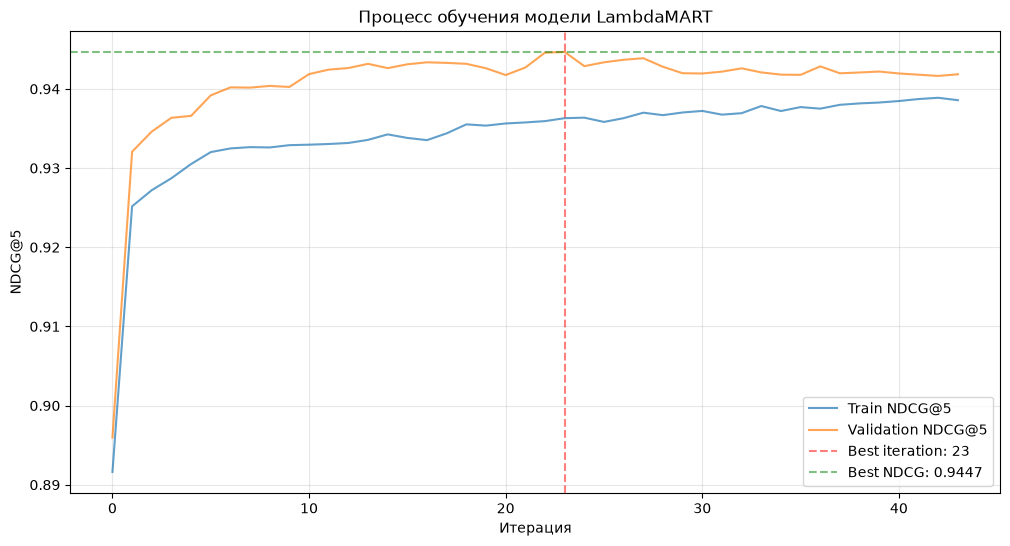

In [ ]:
# Визуализируем процесс обучения
fig, ax = plt.subplots(figsize=(12, 6))

# Извлекаем метрики
train_ndcg = evals_result['train']['ndcg@5']
val_ndcg = evals_result['val']['ndcg@5']
iterations = range(len(train_ndcg))

# Рисуем графики
ax.plot(iterations, train_ndcg, label='Train NDCG@5', alpha=0.7)
ax.plot(iterations, val_ndcg, label='Validation NDCG@5', alpha=0.7)

# Отмечаем лучшую точку
best_iter = model.best_iteration
best_score = model.best_score
ax.axvline(x=best_iter, color='red', linestyle='--', alpha=0.5, label=f'Best iteration: {best_iter}')
ax.axhline(y=best_score, color='green', linestyle='--', alpha=0.5, label=f'Best NDCG: {best_score:.4f}')

ax.set_xlabel('Итерация')
ax.set_ylabel('NDCG@5')
ax.set_title('Процесс обучения модели LambdaMART')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

# Подготовка тестовых данных

In [47]:
# Предобработка тестовых данных
X_test, _, groups_test, _, _ = preprocess_data(
    test_interactions, users, items
)

# Масштабируем тестовые данные
X_test_scaled = scaler.transform(X_test)

print(f"Размерность тестовой выборки: {X_test_scaled.shape}")
print(f"Количество групп (пользователей) в тесте: {len(np.unique(groups_test))}")

Размерность тестовой выборки: (3993, 5)
Количество групп (пользователей) в тесте: 180


# Предсказание на тестовых данных

In [49]:
# Создаем DMatrix для тестовых данных
dtest = xgb.DMatrix(X_test_scaled)

# Делаем предсказания
y_pred = model.predict(dtest, iteration_range=(0, model.best_iteration + 1))

print(f"Предсказания сделаны для {len(y_pred)} записей")
print(f"Диапазон предсказаний: [{y_pred.min():.4f}, {y_pred.max():.4f}]")
print(f"Среднее предсказание: {y_pred.mean():.4f}")

Предсказания сделаны для 3993 записей
Диапазон предсказаний: [-1.4731, 1.4505]
Среднее предсказание: -0.3974


# Постобработка предсказаний

In [50]:
# Так как relevance в обучающей выборке от 1 до 5, 
# но могут быть и другие значения, мы нормализуем предсказания
# и округляем до ближайшего целого, ограничивая диапазон [1, 5]

# Нормализуем предсказания к диапазону [1, 5]
y_pred_normalized = (y_pred - y_pred.min()) / (y_pred.max() - y_pred.min()) * 4 + 1

# Округляем до ближайшего целого
y_pred_rounded = np.round(y_pred_normalized)

# Ограничиваем диапазон
y_pred_final = np.clip(y_pred_rounded, 1, 5)

print("Статистика итоговых предсказаний:")
print(pd.Series(y_pred_final).describe())
print(f"\nРаспределение предсказаний:")
print(pd.Series(y_pred_final).value_counts().sort_index())

Статистика итоговых предсказаний:
count    3993.000000
mean        2.415227
std         1.042142
min         1.000000
25%         2.000000
50%         2.000000
75%         3.000000
max         5.000000
dtype: float64

Распределение предсказаний:
1.0     858
2.0    1342
3.0    1172
4.0     519
5.0     102
Name: count, dtype: int64


# Создание итогового файла с предсказаниями

In [51]:
# Создаем DataFrame с результатами
submission = pd.DataFrame({
    'user_id': test_interactions['user_id'].values,
    'item_id': test_interactions['item_id'].values,
    'relevance': y_pred_final.astype(int)
})

# Проверяем размерность
print(f"Размерность итогового файла: {submission.shape}")
print(f"Ожидаемая размерность: 3993 строки")
print(f"Количество уникальных пользователей: {submission['user_id'].nunique()}")
print(f"Количество уникальных товаров: {submission['item_id'].nunique()}")

# Проверяем первые строки
print("Первые 10 строк итогового файла:")
display(submission.head(10))

# Сохраняем в CSV
submission.to_csv('submission.csv', index=False)
print("Файл 'submission.csv' успешно сохранен!")

Размерность итогового файла: (3993, 3)
Ожидаемая размерность: 3993 строки
Количество уникальных пользователей: 180
Количество уникальных товаров: 120
Первые 10 строк итогового файла:


,user_id,item_id,relevance
0,488,6,2
1,827,114,4
2,626,41,3
3,790,83,1
4,544,10,3
5,780,24,2
6,397,56,3
7,236,53,4
8,345,42,3
9,534,34,3


Файл 'submission.csv' успешно сохранен!


# Проверка NDCG@5 на валидационной выборке

In [53]:
def calculate_ndcg_at_k(y_true, y_pred, groups, k=5):
    """
    Вычисление NDCG@k для групп
    """
    unique_groups = np.unique(groups)
    ndcg_scores = []
    
    for group in unique_groups:
        group_mask = groups == group
        true_relevance = y_true[group_mask]
        pred_relevance = y_pred[group_mask]
        
        # Проверяем, что в группе достаточно элементов
        if len(true_relevance) >= k:
            ndcg = ndcg_score([true_relevance], [pred_relevance], k=k)
            ndcg_scores.append(ndcg)
    
    return np.mean(ndcg_scores)

# Вычисляем NDCG@5 на валидационных данных
# Используем предсказания на валидации
val_pred = model.predict(dval, iteration_range=(0, model.best_iteration + 1))
ndcg_val = calculate_ndcg_at_k(y_val, val_pred, groups_val, k=5)

print(f"NDCG@5 на валидационной выборке: {ndcg_val:.4f}")
print(f"Требуемое минимальное значение: 0.9000")
print(f"Результат: {'Достигнут' if ndcg_val >= 0.9 else 'Требуется улучшение'}")

NDCG@5 на валидационной выборке: 0.9464
Требуемое минимальное значение: 0.9000
Результат: Достигнут


# Дополнительная проверка - анализ ошибок

Статистика ошибок на валидационной выборке:
Средняя ошибка: 3.7983
Стандартное отклонение ошибки: 0.2631


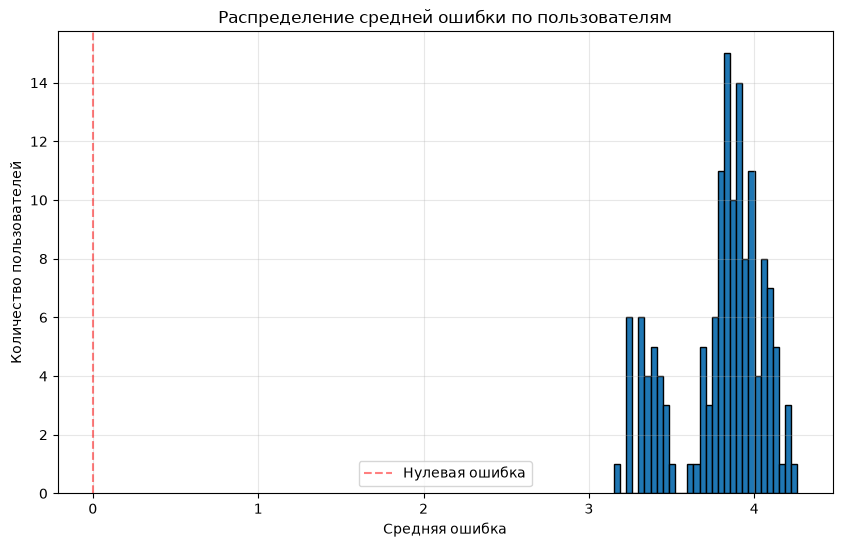

In [54]:
# Сравниваем предсказания с реальными значениями на валидации
val_results = pd.DataFrame({
    'true': y_val,
    'pred': val_pred,
    'user_id': groups_val
})

# Группируем по пользователям и считаем среднюю ошибку
val_results['error'] = val_results['true'] - val_results['pred']
user_errors = val_results.groupby('user_id')['error'].mean()

print("Статистика ошибок на валидационной выборке:")
print(f"Средняя ошибка: {user_errors.mean():.4f}")
print(f"Стандартное отклонение ошибки: {user_errors.std():.4f}")

# Визуализация распределения ошибок
plt.figure(figsize=(10, 6))
user_errors.hist(bins=30, edgecolor='black')
plt.title('Распределение средней ошибки по пользователям')
plt.xlabel('Средняя ошибка')
plt.ylabel('Количество пользователей')
plt.grid(True, alpha=0.3)
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Нулевая ошибка')
plt.legend()
plt.show()

# Итоговый анализ и выводы

In [56]:
print("ИТОГОВЫЙ АНАЛИЗ МОДЕЛИ")
print("="*60)
print(f"1. Размер обучающей выборки: {len(y_train)} записей")
print(f"2. Размер тестовой выборки: {len(y_pred)} записей")
print(f"3. Количество признаков: {X_train.shape[1]}")
print(f"4. Количество пользователей в обучении: {len(np.unique(groups_train))}")
print(f"5. Количество пользователей в тесте: {len(np.unique(groups_test))}")

print(f"6. Параметры модели:")
for key, value in params.items():
    print(f"   - {key}: {value}")

print(f"7. Лучшее количество деревьев: {model.best_iteration}")
print(f"8. Лучшее NDCG@5 на валидации: {model.best_score:.4f}")

print(f"9. NDCG@5 на валидационной выборке: {ndcg_val:.4f}")
print(f"   Требуемый порог: 0.9000")
print(f"   Статус: {'Достигнут' if ndcg_val >= 0.9 else 'Не достигнут'}")

print(f"10. Количество предсказаний в итоговом файле: {len(submission)}")
print(f"11. Итоговый файл сохранен как 'submission.csv'")
print("="*60)

ИТОГОВЫЙ АНАЛИЗ МОДЕЛИ
1. Размер обучающей выборки: 16007 записей
2. Размер тестовой выборки: 3993 записей
3. Количество признаков: 5
4. Количество пользователей в обучении: 720
5. Количество пользователей в тесте: 180
6. Параметры модели:
   - objective: rank:ndcg
   - learning_rate: 0.1
   - max_depth: 6
   - min_child_weight: 5
   - subsample: 0.8
   - colsample_bytree: 0.8
   - eval_metric: ndcg@5
   - early_stopping_rounds: 20
   - verbosity: 0
   - seed: 42
7. Лучшее количество деревьев: 23
8. Лучшее NDCG@5 на валидации: 0.9447
9. NDCG@5 на валидационной выборке: 0.9464
   Требуемый порог: 0.9000
   Статус: Достигнут
10. Количество предсказаний в итоговом файле: 3993
11. Итоговый файл сохранен как 'submission.csv'
